<a href="https://colab.research.google.com/github/prasadnikhil125-CHAUDHARY/business-data-analysis-ai-ml/blob/main/SPAM_DETECTION_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Workshop**
---
## **📩 Spam Detection Project**


## Business Problem
Digital users receive a mix of genuine and unwanted messages. Our goal is to build a **Machine Learning model that classifies a message as `ham` (genuine) or `spam`**.

### What you will build
- Explore a labelled text dataset
- Clean text using simple NLP rules
- Convert words into numbers using **TF-IDF**
- Train a **Multinomial Naive Bayes** classifier
- Evaluate the model using accuracy, precision, recall and a confusion matrix
- Test your own messages with a reusable prediction function

> **Dataset note:**

https://github.com/YBIFoundation/Live-Projects/raw/main/SpamDetectionDataset.csv

In [ ]:
# Step 1: Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

In [ ]:
# Step 2: Import dataset
df = pd.read_csv('https://github.com/YBIFoundation/Live-Projects/raw/main/SpamDetectionDataset.csv')

In [ ]:
df.head()

,message_id,label,message
0,MSG0001,ham,Your OTP for login is 661936. Do not share thi...
1,MSG0002,ham,We have received your application for the inte...
2,MSG0003,ham,Good morning Kabir. Please send the attendance...
3,MSG0004,ham,The Data Analytics assignment deadline is Tues...
4,MSG0005,ham,"Hi, Payment of INR 5000 received successfully...."


In [ ]:
df.label.value_counts()

,count
label,
ham,1050
spam,350


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   message_id  1400 non-null   object
 1   label       1400 non-null   object
 2   message     1400 non-null   object
dtypes: object(3)
memory usage: 32.9+ KB


In [ ]:
X.shape, X_train.shape, X_test.shape

((1400,), (1120,), (280,))

In [ ]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='label'>

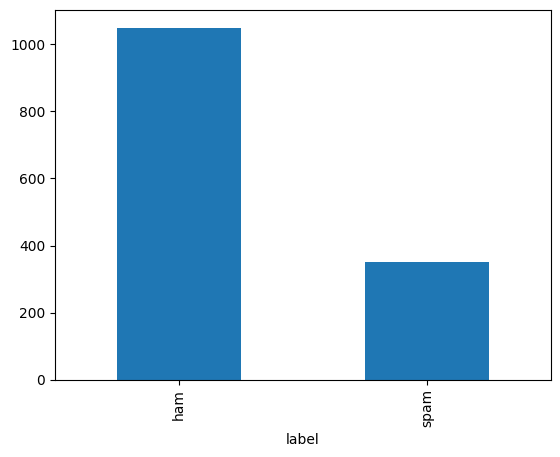

In [ ]:
# Bar chart
df.label.value_counts().plot(kind='bar')

In [ ]:
# Preprocessing
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', ' url ', text)   # replace links
    text = re.sub(r'\d+', ' number ', text)                  # replace numbers
    text = re.sub(r'[^a-z\s]', ' ', text)                    # keep letters/spaces
    text = re.sub(r'\s+', ' ', text).strip()                 # remove extra spaces
    return text

# Create cleaned text column
df['clean_message'] = df['message'].apply(clean_text)

df[['label', 'message', 'clean_message']].head()

,label,message,clean_message
0,ham,Your OTP for login is 661936. Do not share thi...,your otp for login is number do not share this...
1,ham,We have received your application for the inte...,we have received your application for the inte...
2,ham,Good morning Kabir. Please send the attendance...,good morning kabir please send the attendance ...
3,ham,The Data Analytics assignment deadline is Tues...,the data analytics assignment deadline is tues...
4,ham,"Hi, Payment of INR 5000 received successfully....",hi payment of inr number received successfully...


In [ ]:
X = df['clean_message']
y = df['label']

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,  test_size=0.20, random_state=2529, stratify=y)


In [ ]:
# Convert text into numbers
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print('Training matrix shape:', X_train_tfidf.shape)
print('Number of learned features:', len(tfidf.get_feature_names_out()))

Training matrix shape: (1120, 1272)
Number of learned features: 1272


In [ ]:
# Model
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()

In [ ]:
model.fit(X_train_tfidf,y_train)

MultinomialNB()

In [ ]:
y_pred = model.predict(X_test_tfidf)

In [ ]:
y_test

,label
1084,ham
382,spam
249,ham
943,ham
1205,spam
...,...
557,ham
1361,ham
535,spam
1094,ham


In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         ham       1.00      1.00      1.00       210
        spam       1.00      1.00      1.00        70

    accuracy                           1.00       280
   macro avg       1.00      1.00      1.00       280
weighted avg       1.00      1.00      1.00       280

